In [53]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

In [54]:
# Load Dataset
df = pd.read_csv("retail_sales_6months_dataset.csv")
df.head()

,date,store_id,product_category,product_name,units_sold,unit_price,customer_type,revenue
0,2025-01-01,S105,Grocery,Eggs,15,1180,Regular,17700
1,2025-01-01,S102,Electronics,Headphones,19,1288,Loyalty,24472
2,2025-01-01,S105,Grocery,Eggs,4,2969,Regular,11876
3,2025-01-01,S105,Grocery,Milk,2,2441,Regular,4882
4,2025-01-01,S102,Clothing,Jeans,21,1234,Regular,25914


In [55]:
# Basic Dataset Check
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nPreview:")
print(df.head())

Dataset Shape: (2172, 8)

Columns: Index(['date', 'store_id', 'product_category', 'product_name', 'units_sold',
       'unit_price', 'customer_type', 'revenue'],
      dtype='object')

Preview:
         date store_id product_category product_name  units_sold  unit_price  \
0  2025-01-01     S105          Grocery         Eggs          15        1180   
1  2025-01-01     S102      Electronics   Headphones          19        1288   
2  2025-01-01     S105          Grocery         Eggs           4        2969   
3  2025-01-01     S105          Grocery         Milk           2        2441   
4  2025-01-01     S102         Clothing        Jeans          21        1234   

  customer_type  revenue  
0       Regular    17700  
1       Loyalty    24472  
2       Regular    11876  
3       Regular     4882  
4       Regular    25914  


In [56]:
# ANALYSIS 1 — Monthly Revenue Trend

# Convert date column (if not already done)
df["date"] = pd.to_datetime(df["date"])

In [57]:
# Create Month column
df["month"] = df["date"].dt.to_period("M")

In [59]:
# Calculate monthly revenue
monthly_sales = df.groupby("month")["revenue"].sum()
print(monthly_sales)

month
2025-01    9170320
2025-02    8520427
2025-03    9661671
2025-04    9899609
2025-05    9185832
2025-06    8537267
Freq: M, Name: revenue, dtype: int64


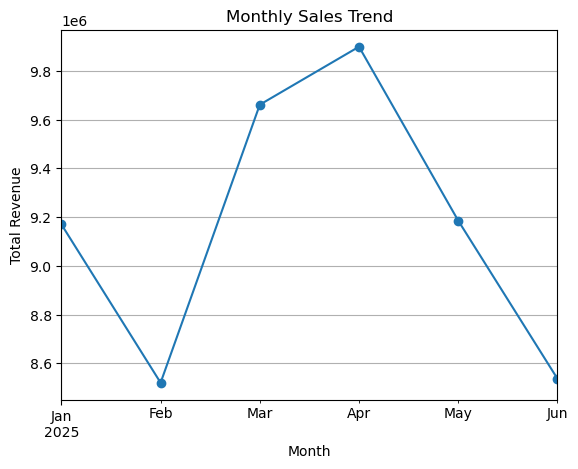

In [60]:
# Plot trend
plt.figure()
monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.grid(True)

plt.show()


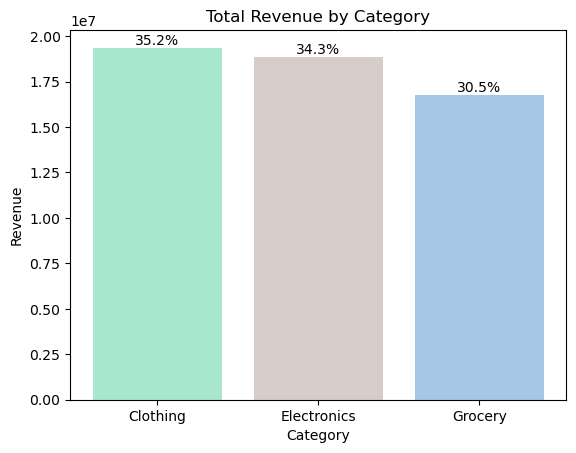

In [62]:
# ANALYSIS 2 — Category Performance

category_sales = df.groupby("product_category")["revenue"].sum()

# Calculate %
category_pct = (category_sales / category_sales.sum()) * 100

colors = ["#A8E6CF", "#D7CCC8", "#A7C7E7"]  # green, brown, blue pastel

plt.figure()

bars = plt.bar(category_sales.index, category_sales.values, color=colors)

# Add % labels
for bar, pct in zip(bars, category_pct):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{pct:.1f}%",
        ha='center',
        va='bottom'
    )

plt.title("Total Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()


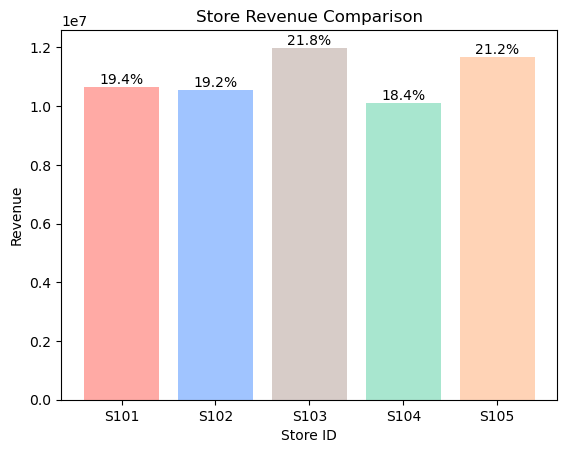

In [64]:
# ANALYSIS 3 — Store Performance

store_sales = df.groupby("store_id")["revenue"].sum()

# Calculate %
store_pct = (store_sales / store_sales.sum()) * 100

colors = ["#FFAAA5", "#A0C4FF", "#D7CCC8", "#A8E6CF", "#FFD3B6"]

plt.figure()

bars = plt.bar(store_sales.index, store_sales.values, color=colors)

# Add % labels
for bar, pct in zip(bars, store_pct):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{pct:.1f}%",
        ha='center',
        va='bottom'
    )

plt.title("Store Revenue Comparison")
plt.xlabel("Store ID")
plt.ylabel("Revenue")

plt.show()


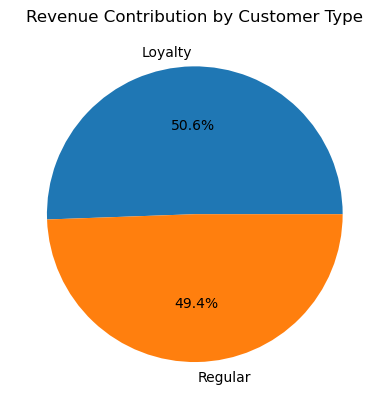

In [65]:
# ANALYSIS 4 — Customer Type Contribution

customer_sales = df.groupby("customer_type")["revenue"].sum()

plt.figure()
customer_sales.plot(kind="pie", autopct="%1.1f%%")
plt.title("Revenue Contribution by Customer Type")
plt.ylabel("")
plt.show()


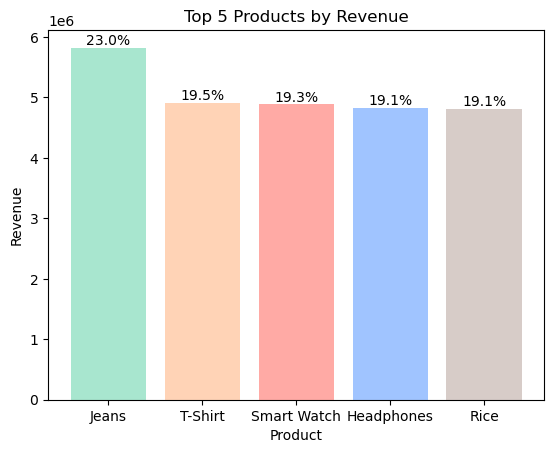

In [66]:
# ANALYSIS 5 — Top 5 Products

top_products = df.groupby("product_name")["revenue"].sum().sort_values(ascending=False).head(5)

# Calculate percentage contribution
percentages = (top_products / top_products.sum()) * 100

colors = ["#A8E6CF", "#FFD3B6", "#FFAAA5", "#A0C4FF", "#D7CCC8"]  # pastel colors

plt.figure()

bars = plt.bar(top_products.index, top_products.values, color=colors)

# Add % labels on top
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{pct:.1f}%",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Top 5 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.show()
